# ECO491: Homework 4

In [25]:
# Basic python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import norm
from arch import arch_model

import os

Iteration:      1,   Func. Count:      6,   Neg. LLF: 4583908834.796002
Iteration:      2,   Func. Count:     19,   Neg. LLF: 247083.7380273005
Iteration:      3,   Func. Count:     30,   Neg. LLF: 259394072177.39185
Iteration:      4,   Func. Count:     44,   Neg. LLF: 1571008444.2977343
Optimization terminated successfully    (Exit mode 0)
            Current function value: -9750.329016236556
            Iterations: 5
            Function evaluations: 54
            Gradient evaluations: 4


/opt/anaconda3/lib/python3.13/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004482. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


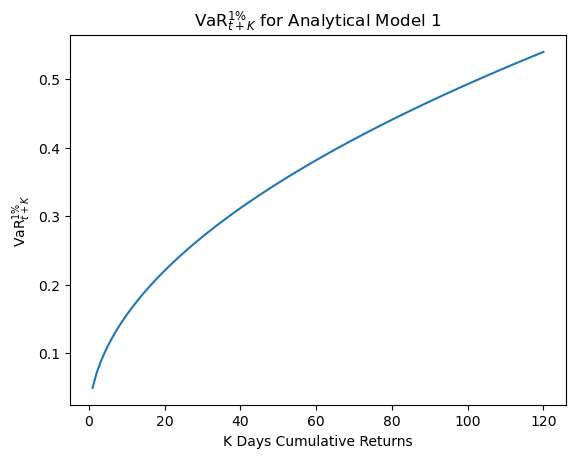

Plot saved to: ../latex/figures/ECO491_HW4_Q1_Model_2.pdf


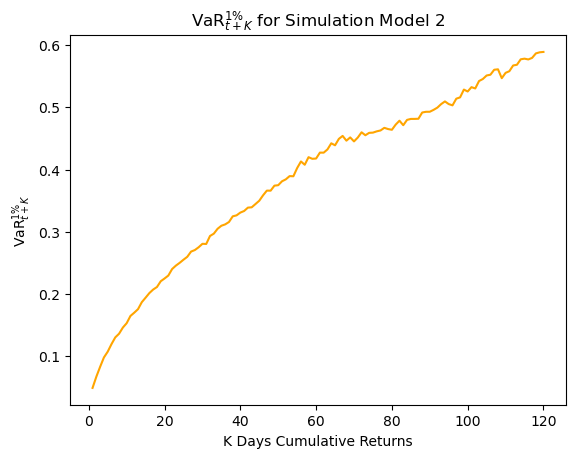

In [ ]:
# Question 1.2 Coding Portion

# == Cleaning stock data ==
stock = pd.read_excel("../data/BAC_2010_2024-1.xlsx")
returns = stock.assign(
    Date=pd.to_datetime(stock["Date"]),
    Returns=stock["Close Price"].pct_change()
).dropna(subset=["Returns"]).set_index("Date")[["Returns"]]

# == GARCH(1,1) fitting ==
model = arch_model(returns, vol = "GARCH", p=1,q=1, mean='Constant', dist='normal')
results = model.fit()

omega = results.params['omega']
alpha = results.params['alpha[1]']
beta = results.params['beta[1]']

def GARCH_Model(R, sigma):
  return omega + alpha * R**2 + beta * sigma

# == Parameters ==
t = pd.to_datetime("2024-12-19")
K = 120
t_var = np.var(returns.loc[:t, "Returns"])

# == Model 1 ==
t1_var = GARCH_Model(returns["Returns"][t],t_var)

test_VaR = []
for k in range(1,K+1):
  test_VaR.append(-np.sqrt(k) * np.sqrt(t_var) * norm.ppf(.01))

x = np.arange(1, len(test_VaR) + 1)
plt.plot(x, test_VaR)
plt.xlabel("K Days Cumulative Returns")
plt.ylabel(r"$\text{VaR}_{t+K}^{1\%}$")
plt.title(r"$\text{VaR}_{t+K}^{1\%}\text{ for Analytical Model 1}$")
plt.show()

# save_folder = "../latex/figures"
# os.makedirs(save_folder, exist_ok=True)
# save_path = os.path.join(save_folder, "ECO491_HW4_Q1_Model_1.pdf")

# plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")
# print(f"Plot saved to: {save_path}")

# Model 2
VaR_values = []
n_scenarios = 10000

start = np.empty((n_scenarios, 3))
start[:, 0] = returns["Returns"][t]
start[:, 1] = t_var
start[:, 2] = t1_var

simulations = [start]

cumulative_log_returns_20 = np.zeros(n_scenarios)

cumulative_log_returns = np.zeros(n_scenarios)

for step in range(1, K + 1):
    prev_matrix = simulations[-1]
    shocks = np.random.normal(0, 1, n_scenarios)
    Ri = np.sqrt(prev_matrix[:, 2]) * shocks
    cumulative_log_returns += np.log(1 + Ri)
    if(step<=20):
       cumulative_log_returns_20 += np.log(1 + Ri)
    ti_var = GARCH_Model(prev_matrix[:, 0], prev_matrix[:, 2])
    new_matrix = np.column_stack([Ri, prev_matrix[:, 2], ti_var])
    simulations.append(new_matrix)
    VaR_1pct = np.percentile(cumulative_log_returns, 1)
    VaR_values.append(-VaR_1pct)

# VaR_values = [1-x for x in VaR_values]

plt.plot(x, VaR_values, color="orange")
plt.xlabel("K Days Cumulative Returns")
plt.ylabel(r"$\text{VaR}_{t+K}^{1\%}$")
plt.title(r"$\text{VaR}_{t+K}^{1\%}\text{ for Simulation Model 2}$")

os.makedirs(save_folder, exist_ok=True)
save_path = os.path.join(save_folder, "ECO491_HW4_Q1_Model_2.pdf")

plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")
print(f"Plot saved to: {save_path}")

Plot saved to: ../latex/figures/ECO491_HW4_Q1_Superimpose.pdf


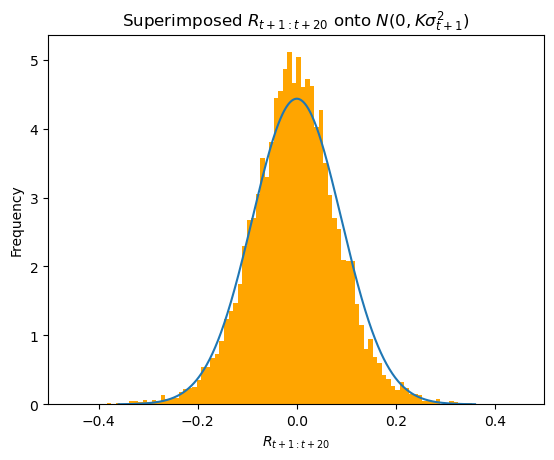

In [27]:
# Question 1.3 Coding Portion

x = np.linspace(-4 * np.sqrt(20 * t1_var), 4 * np.sqrt(20 * t1_var), 1000)
pdf = norm.pdf(x, 0, np.sqrt(20 * t1_var))

plt.hist(cumulative_log_returns_20, 100, density=True, color = "orange")
plt.plot(x, pdf)
plt.ylabel("Frequency")
plt.xlabel(r"$ R_{t+1:t+20}$")
plt.title(r"$ \text{Superimposed } R_{t+1:t+20} \text{ onto } N(0,K \sigma_{t+1}^2) $")

os.makedirs(save_folder, exist_ok=True)
save_path = os.path.join(save_folder, "ECO491_HW4_Q1_Superimpose.pdf")

plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")
print(f"Plot saved to: {save_path}")

Plot saved to: ../latex/figures/ECO491_HW4_Q2.1_HS.pdf


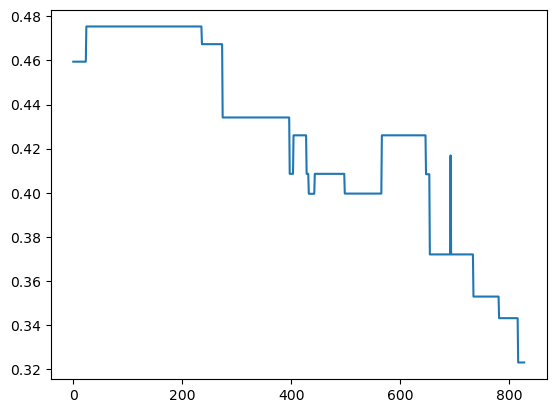

In [28]:
# Question 2.1 Coding Portion

# == Cleaning yield data ==
yields = pd.read_excel("../data/YTM_US2001_2025-1.xlsx")
yields["Date"] = pd.to_datetime(yields["Date"])
yields = yields.set_index("Date")

t = pd.to_datetime("2021-07-01")
yields = yields.loc[yields.index>=t]
yields = yields.drop(columns=["t", "t complete"])

yields["Price"] = 100 * np.exp(-yields["DGS3"]*3)
yields["Returns"] = yields["Price"].pct_change()

VaR_HS_Bonds = -1 * yields["Returns"].rolling(window=250).apply(lambda x: np.percentile(x, 1)).dropna()
x = np.linspace(0, len(VaR_HS_Bonds)-1, len(VaR_HS_Bonds))
plt.plot(x, VaR_HS_Bonds)

os.makedirs(save_folder, exist_ok=True)
save_path = os.path.join(save_folder, "ECO491_HW4_Q2.1_HS.pdf")

plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")
print(f"Plot saved to: {save_path}")

Plot saved to: ../latex/figures/ECO491_HW4_Q2.3Yv5Y.pdf
Plot saved to: ../latex/figures/ECO491_HW4_Q2.Something.pdf


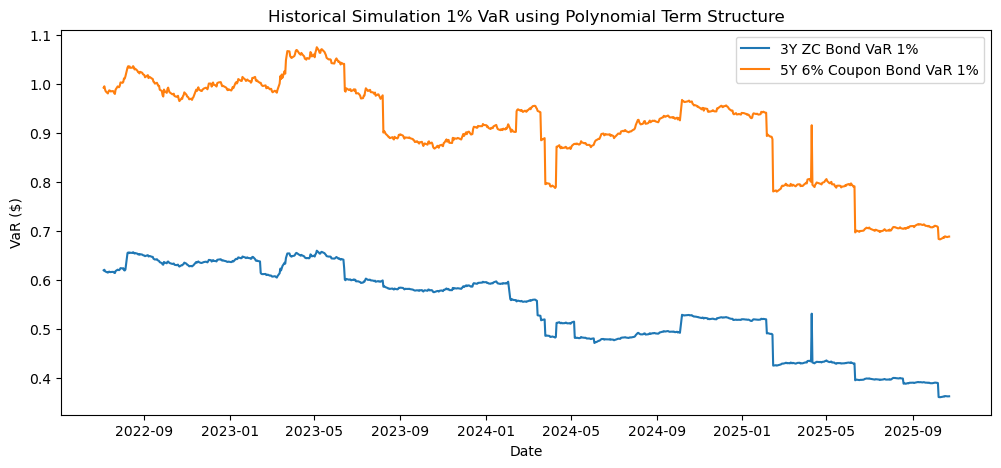

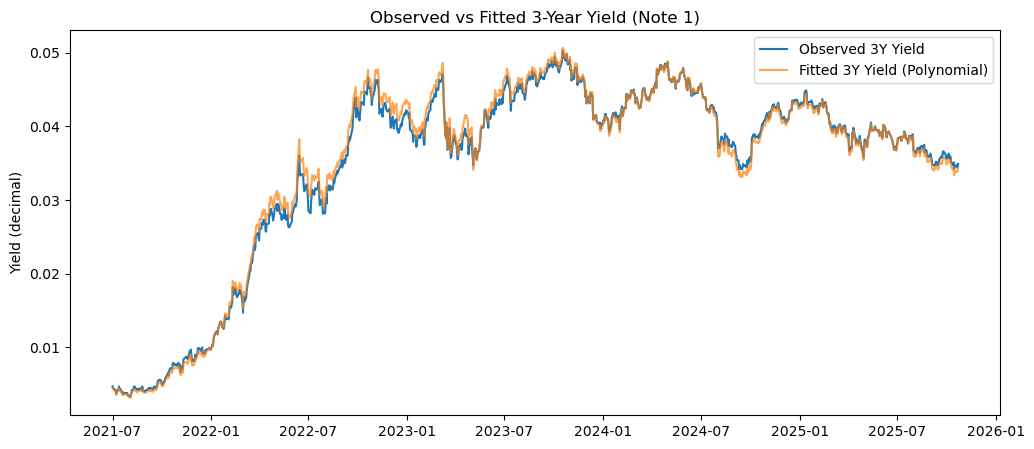

In [29]:
# ============================
# QUESTION 2.2 — FULLY CORRECTED CODE
# ============================

yield_cols = ["DGS1MO","DGS3MO","DGS6MO","DGS1","DGS2","DGS3","DGS5","DGS7","DGS10"]

# Convert yields from percent → decimal
yields[yield_cols] = yields[yield_cols] / 100

maturities = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10])
beta_df = pd.DataFrame(index=yields.index, columns=["beta1","beta2","beta3","beta4"])

# ============================
# Fit polynomial regression
# ============================
for t in yields.index:
    y = yields.loc[t, yield_cols].values
    X = np.vstack([np.ones_like(maturities), maturities, maturities**2, maturities**3]).T
    model = LinearRegression(fit_intercept=False)
    model.fit(X, y)
    beta_df.loc[t] = model.coef_

delta_beta = beta_df.diff().dropna()

# ============================
# Yield and pricing functions
# ============================
def yield_poly(T, beta):
    return beta[0] + beta[1]*T + beta[2]*T**2 + beta[3]*T**3

def zero_coupon_price(face, T, beta):
    R = yield_poly(T, beta)
    return face * np.exp(-R*T)

def coupon_bond_price(face, coupon_rate, T, beta, freq=2):
    coupon = face * coupon_rate / freq
    times = np.arange(1/freq, T + 1/freq, 1/freq)
    discounts = np.exp(-yield_poly(times, beta)*times)
    pv_coupons = np.sum(coupon * discounts)
    pv_face = face * np.exp(-yield_poly(T, beta) * T)
    return pv_coupons + pv_face

def duration_coupon(face, coupon_rate, T, beta, freq=2):
    coupon = face * coupon_rate / freq
    times = np.arange(1/freq, T + 1/freq, 1/freq)
    discounts = np.exp(-yield_poly(times, beta)*times)
    price = coupon_bond_price(face, coupon_rate, T, beta, freq)
    weighted = times * coupon * discounts
    weighted[-1] += T * face * np.exp(-yield_poly(T, beta) * T)
    return np.sum(weighted) / price

# ============================
# APPLY CORRECT ΔP FORMULAS
# ============================

window = 250
face = 100

VaR_3Y_ZC = []
VaR_5Y_Coupon = []
dates = delta_beta.index[window:]

for i in range(window, len(delta_beta)):
    delta_window = delta_beta.iloc[i-window:i].values
    beta_t = beta_df.iloc[i].values

    # ---- ZC BOND ----
    price_t = zero_coupon_price(face, 3, beta_t)
    R_t = yield_poly(3, beta_t)
    carry = np.exp(R_t/252)

    deltaP_3Y = []
    for db in delta_window:
        price_t1 = zero_coupon_price(face, 3 - 1/252, beta_t + db)
        deltaP_3Y.append(price_t1 - price_t * carry)

    # ---- COUPON BOND ----
    price_t_5Y = coupon_bond_price(face, 0.06, 5, beta_t)
    R_t_5Y = yield_poly(5, beta_t)
    carry_cb = np.exp(R_t_5Y / 252)

    deltaP_5Y = []
    for db in delta_window:
        price_t1_5Y = coupon_bond_price(face, 0.06, 5 - 1/252, beta_t + db)
        deltaP_5Y.append(price_t1_5Y - price_t_5Y * carry_cb)

    VaR_3Y_ZC.append(-np.percentile(deltaP_3Y, 1))
    VaR_5Y_Coupon.append(-np.percentile(deltaP_5Y, 1))

VaR_3Y_ZC = pd.Series(VaR_3Y_ZC, index=dates)
VaR_5Y_Coupon = pd.Series(VaR_5Y_Coupon, index=dates)

# ============================
# PLOT VaRs
# ============================
plt.figure(figsize=(12,5))
plt.plot(VaR_3Y_ZC, label="3Y ZC Bond VaR 1%")
plt.plot(VaR_5Y_Coupon, label="5Y 6% Coupon Bond VaR 1%")
plt.title("Historical Simulation 1% VaR using Polynomial Term Structure")
plt.xlabel("Date")
plt.ylabel("VaR ($)")
plt.legend()

os.makedirs(save_folder, exist_ok=True)
save_path = os.path.join(save_folder, "ECO491_HW4_Q2.3Yv5Y.pdf")

plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")
print(f"Plot saved to: {save_path}")

# ============================
# NOTE 1 GRAPH — OBSERVED vs FITTED 3Y YIELD
# ============================
fitted_3Y = [yield_poly(3, beta_df.iloc[i].values) for i in range(len(beta_df))]

plt.figure(figsize=(12,5))
plt.plot(yields.index, yields["DGS3"], label="Observed 3Y Yield")
plt.plot(yields.index, fitted_3Y, label="Fitted 3Y Yield (Polynomial)", alpha=0.7)
plt.title("Observed vs Fitted 3-Year Yield (Note 1)")
plt.ylabel("Yield (decimal)")
plt.legend()

save_path = os.path.join(save_folder, "ECO491_HW4_Q2.Something.pdf")

plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")
print(f"Plot saved to: {save_path}")


Plot saved to: ../latex/figures/ECO491_HW4_Q2.2_β1.pdf
Plot saved to: ../latex/figures/ECO491_HW4_Q2.2_β2.pdf
Plot saved to: ../latex/figures/ECO491_HW4_Q2.2_β3.pdf
Plot saved to: ../latex/figures/ECO491_HW4_Q2.2_β4.pdf


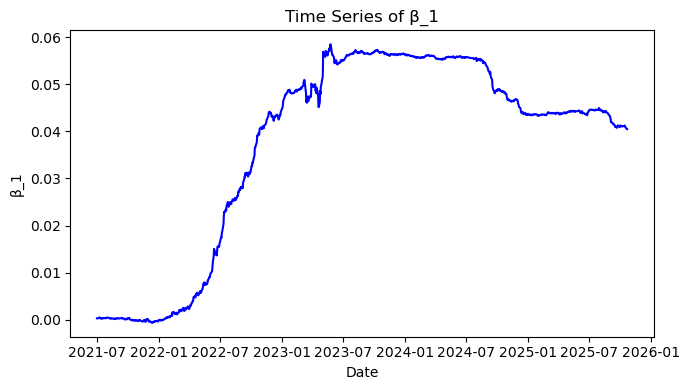

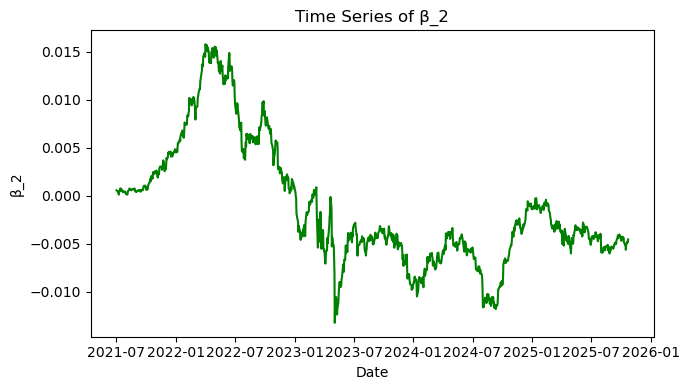

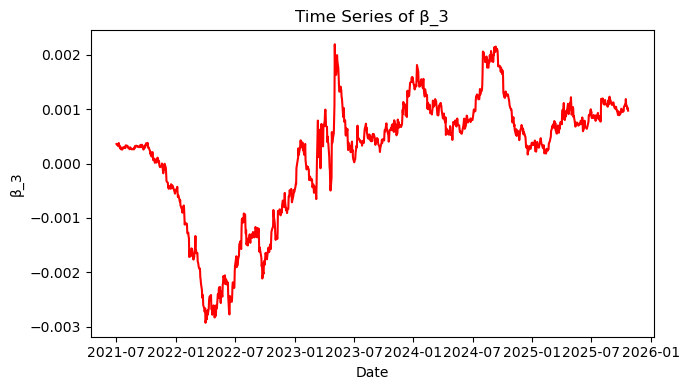

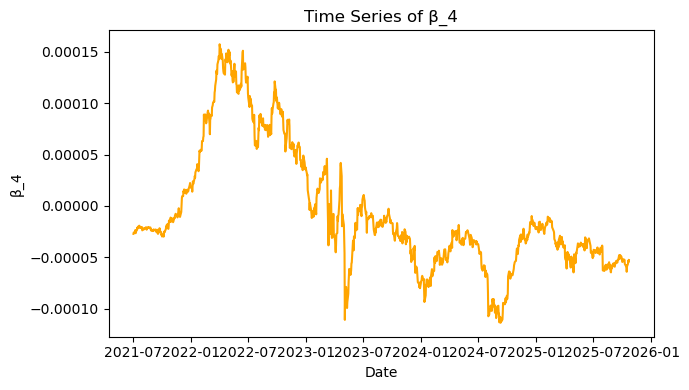

In [30]:
colors = ["blue", "green", "red", "orange"]

for i, col in enumerate(beta_df.columns, start=1):
    plt.figure(figsize=(7,4))
    plt.plot(beta_df.index, beta_df[col], color=colors[i-1])
    plt.title(f"Time Series of β_{i}")
    plt.xlabel("Date")
    plt.ylabel(f"β_{i}")
    plt.tight_layout()
    
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, f"ECO491_HW4_Q2.2_β{i}.pdf")

    plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")
    print(f"Plot saved to: {save_path}")


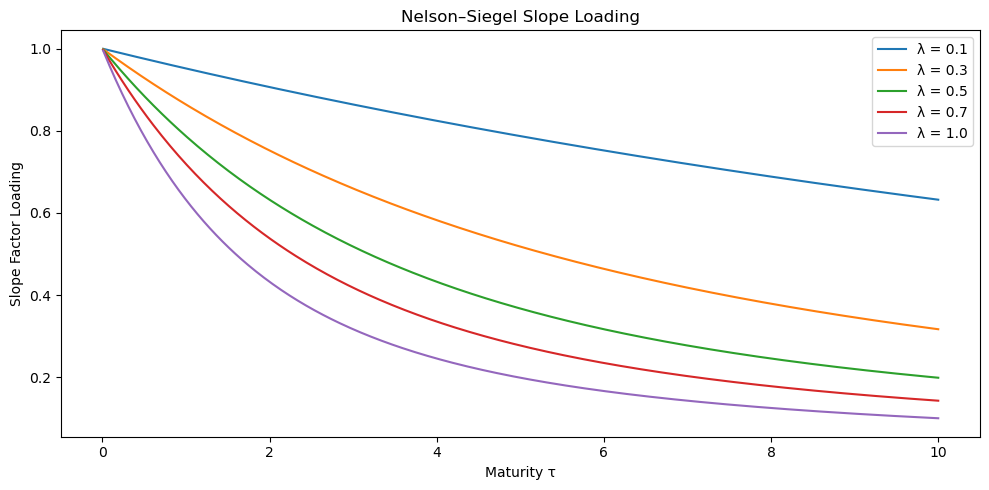

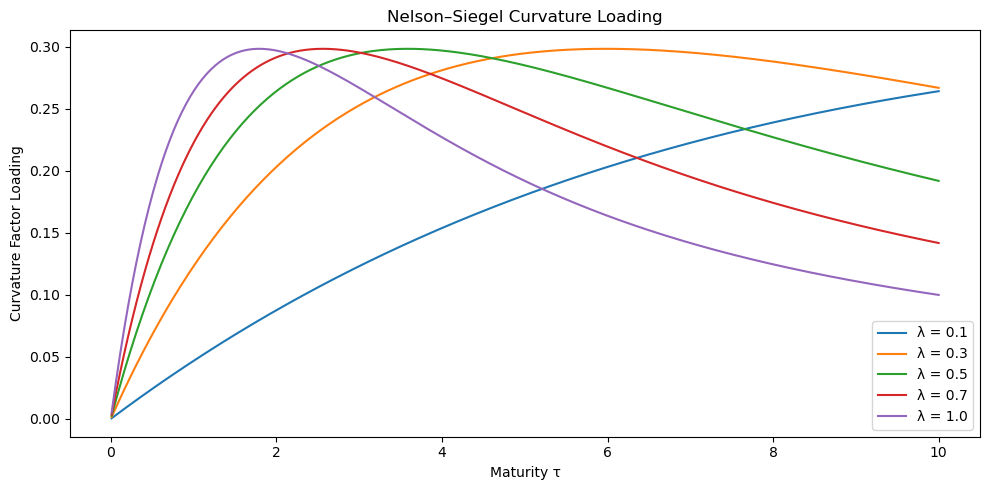

In [31]:
# Question 3

def slope(tau, lam):
    return (1 - np.exp(-lam * tau)) / (lam * tau)

def curvature(tau, lam):
    return (1 - np.exp(-lam * tau)) / (lam * tau) - np.exp(-lam * tau)

tau = np.linspace(0.01, 10, 400)
lambdas = [0.1, 0.3, 0.5, 0.7, 1.0]

# --- Plot Slope Factors ---
plt.figure(figsize=(10,5))
for lam in lambdas:
    plt.plot(tau, slope(tau, lam), label=f'λ = {lam}')
plt.title('Nelson–Siegel Slope Loading')
plt.xlabel('Maturity τ')
plt.ylabel('Slope Factor Loading')
plt.legend()
plt.tight_layout()

os.makedirs(save_folder, exist_ok=True)
save_path = os.path.join(save_folder, f"ECO491_HW4_Q3_Slope.pdf")

plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")

# --- Plot Curvature Factors ---
plt.figure(figsize=(10,5))
for lam in lambdas:
    plt.plot(tau, curvature(tau, lam), label=f'λ = {lam}')
plt.title('Nelson–Siegel Curvature Loading')
plt.xlabel('Maturity τ')
plt.ylabel('Curvature Factor Loading')
plt.legend()
plt.tight_layout()

os.makedirs(save_folder, exist_ok=True)
save_path = os.path.join(save_folder, f"ECO491_HW4_Q3_Curvature.pdf")

plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")